In [3]:
import json
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

# ── Chemins ───────────────────────────────────────────────────────────────────
REPO_DIR    = Path(globals()['_dh'][0]).parent
RESULTS_DIR = REPO_DIR / 'scripts' / 'results'

JSON_FILES = {
    'benchmark': RESULTS_DIR / 'benchmark_results.json',
    'ablation':  RESULTS_DIR / 'ablation_all.json',
    'optim':     RESULTS_DIR / 'optim_results.json',
    'final':     RESULTS_DIR / 'final_results.json',
}

data = {}
for key, path in JSON_FILES.items():
    if path.exists():
        with open(path) as f:
            data[key] = json.load(f)
        print(f'  ✓  {key:<12}  {len(data[key])} entrées  →  {path}')
    else:
        print(f'  ✗  {key:<12}  non trouvé  →  {path}')

# ── Helper affichage ──────────────────────────────────────────────────────────
def fmt(df):
    df = df.copy()
    for c in ['val_acc','train_acc']:
        if c in df: df[c] = df[c].map(lambda x: f'{x:.2f}%')
    if 'val_loss' in df: df['val_loss'] = df['val_loss'].map(lambda x: f'{x:.4f}')
    if 'n_params' in df: df['n_params'] = df['n_params'].map(lambda x: f'{int(x):,}')
    if 'time'     in df: df['time']     = df['time'].map(lambda x: f'{int(x)}s')
    if 'alpha'    in df: df['alpha']    = df['alpha'].map(lambda x: f'{x:.3f}' if pd.notna(x) else '—')
    return df.style \
        .set_table_styles([{'selector':'th','props':'background:#f0f0f0;font-weight:bold;padding:6px 12px;'},
                           {'selector':'td','props':'padding:5px 12px;'},
                           {'selector':'tr:nth-child(even)','props':'background:#fafafa;'}]) \
        .hide(axis='index')

# ══════════════════════════════════════════════════════════════════════════════
# 1. BENCHMARK FINAL — Adapter vs Finetune vs Sidetune (50k, 10ep)
# ══════════════════════════════════════════════════════════════════════════════
display(HTML('<h3>① Benchmark Final — 50k train, 10 epochs</h3>'))
if 'final' in data:
    df = pd.DataFrame(data['final']).sort_values('val_acc', ascending=False)
    display(fmt(df[['method','val_acc','train_acc','val_loss','n_params','time']]))

# ══════════════════════════════════════════════════════════════════════════════
# 2. BENCHMARK 20k — 7 méthodes PEFT
# ══════════════════════════════════════════════════════════════════════════════
display(HTML('<h3>② Benchmark 7 méthodes — 20k train, 10 epochs</h3>'))
if 'benchmark' in data:
    df = pd.DataFrame(data['benchmark'])
    df['acc_per_M'] = (df['val_acc'] / (df['n_params'] / 1e6)).round(1)
    df = df.sort_values('val_acc', ascending=False)
    display(fmt(df[['method','val_acc','train_acc','val_loss','n_params','acc_per_M','time']]))

# ══════════════════════════════════════════════════════════════════════════════
# 3. ABLATION — side size / merge / base
# ══════════════════════════════════════════════════════════════════════════════
display(HTML('<h3>③ Ablation Side-Tuning — 20k train, 10 epochs</h3>'))
if 'ablation' in data:
    df   = pd.DataFrame(data['ablation']).sort_values('val_acc', ascending=False)
    cols = [c for c in ['name','val_acc','train_acc','val_loss','n_params','alpha','time'] if c in df]
    display(fmt(df[cols]))

# ══════════════════════════════════════════════════════════════════════════════
# 4. OPTIM — grille side_size × epochs (tableau + pivot coloré)
# ══════════════════════════════════════════════════════════════════════════════
display(HTML('<h3>④ Grille side_size × epochs — Base=RN50, Merge=MLP</h3>'))
if 'optim' in data:
    df = pd.DataFrame(data['optim']).sort_values('val_acc', ascending=False)
    display(fmt(df[['name','side','epochs','val_acc','train_acc','val_loss']]))
    display(HTML('<b>Pivot val_acc :</b>'))
    pivot = df.pivot(index='side', columns='epochs', values='val_acc').reindex(['small','medium','large'])
    pivot.columns = [f'{c} ep.' for c in pivot.columns]
    display(pivot.style.format('{:.2f}%').background_gradient(cmap='YlGn', axis=None)
                       .set_caption('Val Accuracy — RN50 + MLP'))

  ✓  benchmark     7 entrées  →  c:\Users\user\Desktop\3A\0 - P2\APM583 Deep Learning\Project_SIDE-TUNING\side-tuning\scripts\results\benchmark_results.json
  ✓  ablation      8 entrées  →  c:\Users\user\Desktop\3A\0 - P2\APM583 Deep Learning\Project_SIDE-TUNING\side-tuning\scripts\results\ablation_all.json
  ✓  optim         9 entrées  →  c:\Users\user\Desktop\3A\0 - P2\APM583 Deep Learning\Project_SIDE-TUNING\side-tuning\scripts\results\optim_results.json
  ✓  final         3 entrées  →  c:\Users\user\Desktop\3A\0 - P2\APM583 Deep Learning\Project_SIDE-TUNING\side-tuning\scripts\results\final_results.json


method,val_acc,train_acc,val_loss,n_params,time
adapter,88.40%,93.83%,0.0065,"507,394",1026s
finetune,87.55%,97.06%,0.0113,"23,512,130",1585s
sidetune,85.60%,90.70%,0.0070,"2,931,458",1129s


method,val_acc,train_acc,val_loss,n_params,acc_per_M,time
adapter,86.65%,92.62%,0.0064,"507,394",170.800000,313s
finetune,86.10%,95.85%,0.0119,"23,512,130",3.700000,441s
sidetune,82.65%,88.42%,0.0071,"2,931,458",28.200000,406s
bitfit,82.65%,85.83%,0.0067,"30,658",2695.900000,322s
prompt_tuning,81.65%,83.37%,0.0069,"672,770",121.400000,204s
lora,81.60%,81.89%,0.0071,"4,098",19912.200000,207s
features,80.85%,81.91%,0.0072,"4,098",19729.100000,221s


name,val_acc,train_acc,val_loss,n_params,alpha,time
merge_mlp,83.70%,85.55%,0.0064,"947,778",—,222s
base_rn50,82.50%,85.37%,0.0070,"1,209,411",0.258,278s
side_large,81.55%,87.45%,0.0085,"1,094,915",0.372,396s
merge_product,81.30%,84.71%,0.0066,"160,322",—,217s
base_rn18,81.15%,84.43%,0.0073,"160,323",0.359,221s
side_small,79.30%,83.55%,0.0073,"53,699",0.380,217s
merge_alpha,78.70%,84.32%,0.0081,"160,323",0.397,225s
side_medium,77.05%,84.08%,0.0083,"160,323",0.370,216s


name,side,epochs,val_acc,train_acc,val_loss
rn50_mlp_large_ep10,large,10,85.90%,87.69%,0.0060
rn50_mlp_medium_ep05,medium,5,83.20%,84.12%,0.0075
rn50_mlp_medium_ep10,medium,10,83.00%,85.86%,0.0071
rn50_mlp_medium_ep20,medium,20,82.40%,88.09%,0.0075
rn50_mlp_small_ep05,small,5,81.40%,83.94%,0.0077
rn50_mlp_small_ep20,small,20,80.05%,87.41%,0.0088
rn50_mlp_large_ep05,large,5,79.75%,86.08%,0.0077
rn50_mlp_small_ep10,small,10,79.30%,85.57%,0.0091
rn50_mlp_large_ep20,large,20,79.00%,89.93%,0.0116


,5 ep.,10 ep.,20 ep.
side,,,
small,81.40%,79.30%,80.05%
medium,83.20%,83.00%,82.40%
large,79.75%,85.90%,79.00%


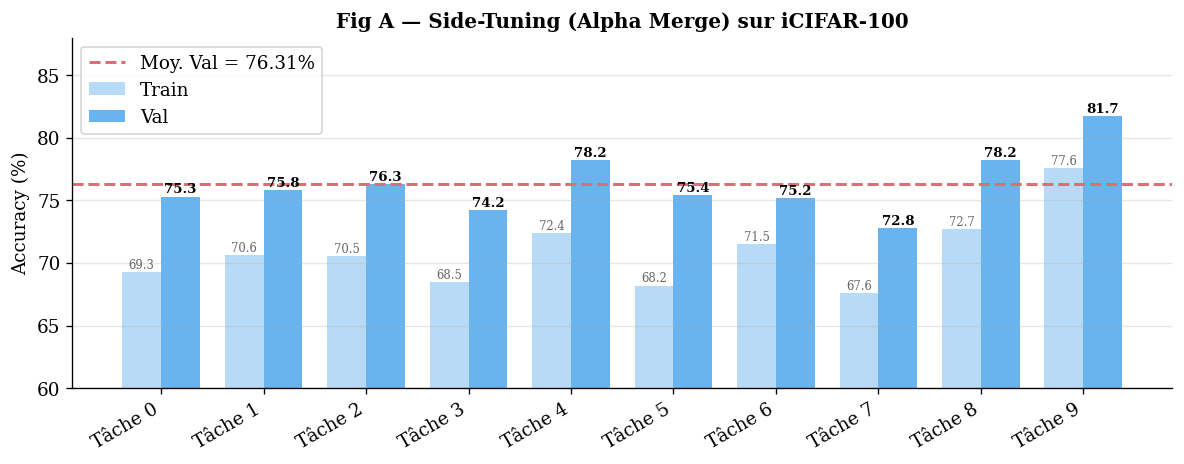

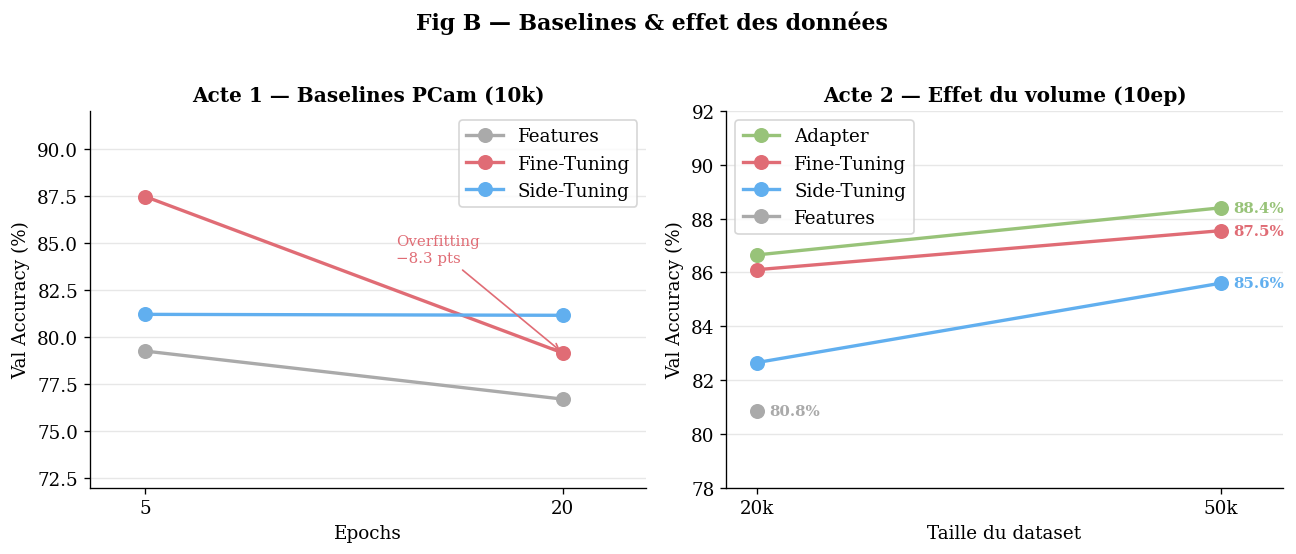

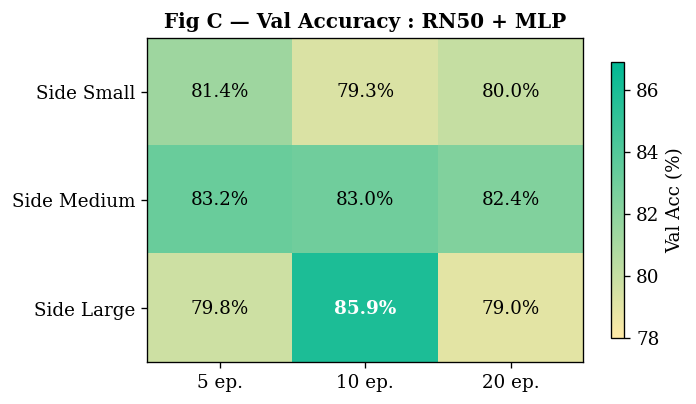

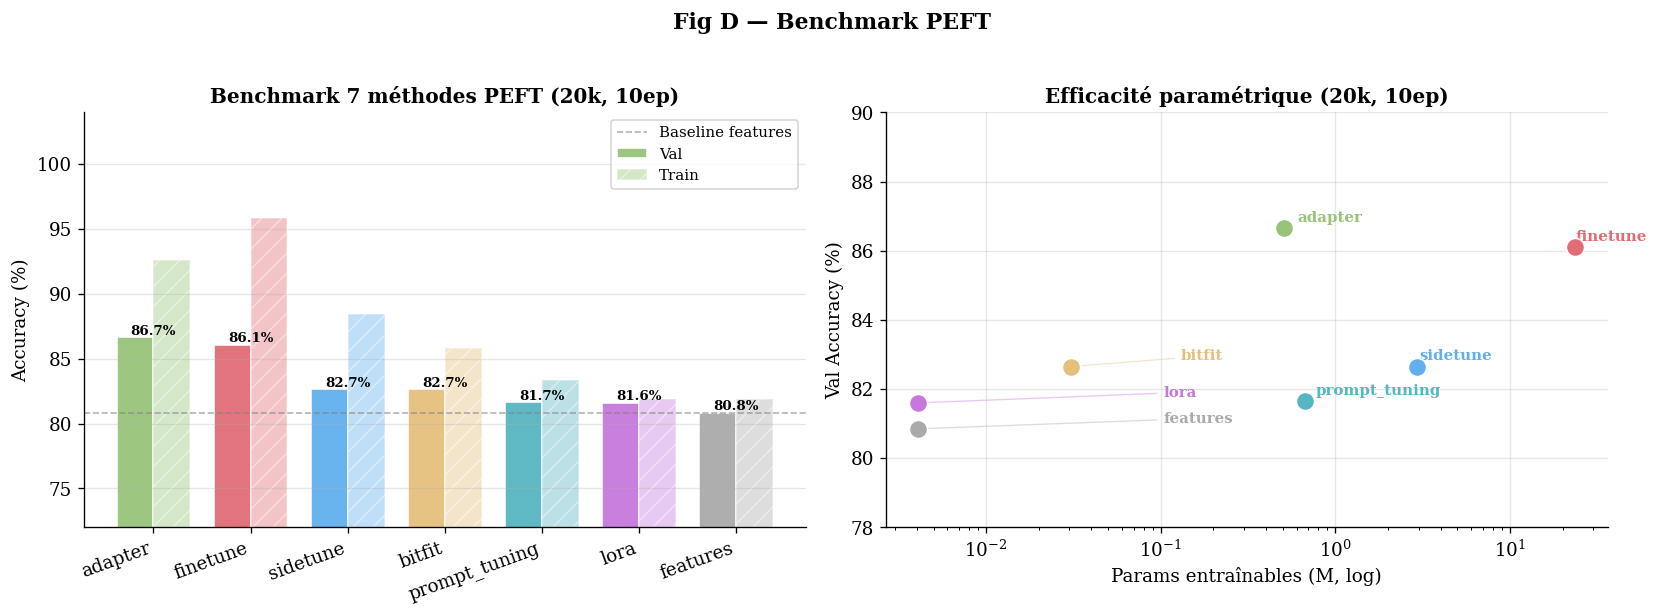

C:\Users\user\AppData\Local\Temp\ipykernel_103412\3985243302.py:184: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  ax.legend(); clean(ax); plt.tight_layout(); plt.show()


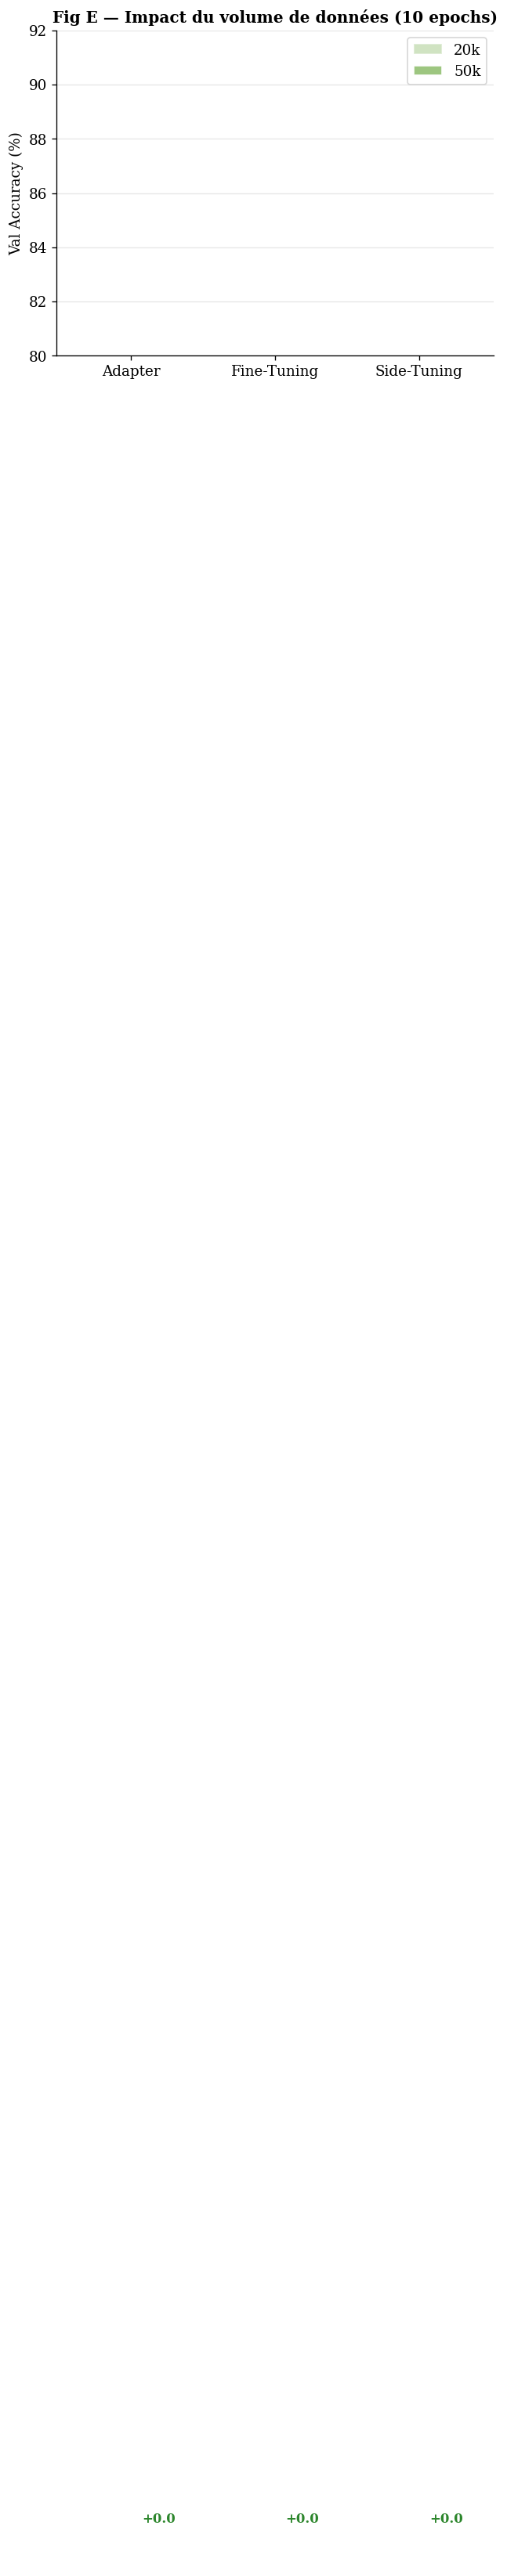

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

%matplotlib inline
matplotlib.rcParams.update({'font.family':'serif','font.size':11,'axes.titlesize':12,'figure.dpi':120})

COLORS = {
    'features':'#aaaaaa','Features':'#aaaaaa',
    'finetune':'#e06c75','Finetune':'#e06c75','Fine-Tuning':'#e06c75',
    'sidetune':'#61afef','Side-Tuning':'#61afef',
    'adapter':'#98c379','Adapter':'#98c379',
    'lora':'#c678dd','LoRA':'#c678dd',
    'bitfit':'#e5c07b','BitFit':'#e5c07b',
    'prompt_tuning':'#56b6c2','Prompt Tuning':'#56b6c2',
}

def clean(ax):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', alpha=0.3)

# ── Données (JSON si dispo, sinon fallback) ───────────────────────────────────
bench_20k = sorted(data.get('benchmark', [
    {'method':'Adapter',      'val_acc':86.65,'train_acc':92.62,'val_loss':0.0064,'n_params':507394},
    {'method':'Finetune',     'val_acc':86.10,'train_acc':95.85,'val_loss':0.0119,'n_params':23512130},
    {'method':'Side-Tuning',  'val_acc':82.65,'train_acc':88.42,'val_loss':0.0071,'n_params':2931458},
    {'method':'BitFit',       'val_acc':82.65,'train_acc':85.83,'val_loss':0.0067,'n_params':30658},
    {'method':'Prompt Tuning','val_acc':81.65,'train_acc':83.37,'val_loss':0.0069,'n_params':672770},
    {'method':'LoRA',         'val_acc':81.60,'train_acc':81.89,'val_loss':0.0071,'n_params':4098},
    {'method':'Features',     'val_acc':80.85,'train_acc':81.91,'val_loss':0.0072,'n_params':4098},
]), key=lambda x: x['val_acc'], reverse=True)

bench_final = data.get('final', [
    {'method':'Adapter',    'val_acc':88.40,'train_acc':93.83},
    {'method':'Finetune',   'val_acc':87.55,'train_acc':97.06},
    {'method':'Side-Tuning','val_acc':85.60,'train_acc':90.70},
])

ICIFAR = {
    'train':[69.28,70.62,70.54,68.47,72.36,68.20,71.48,67.60,72.70,77.57],
    'val':  [75.30,75.80,76.30,74.20,78.20,75.40,75.20,72.80,78.20,81.70],
    'avg':  76.31
}

# ══════════════════════════════════════════════════════════════════════════════
# Fig A — iCIFAR par tâche
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 4))
x, w = np.arange(10), 0.38
ax.bar(x-w/2, ICIFAR['train'], w, color='#61afef', alpha=0.45, label='Train')
ax.bar(x+w/2, ICIFAR['val'],   w, color='#61afef', alpha=0.95, label='Val')
ax.axhline(ICIFAR['avg'], color='#e06c75', ls='--', lw=1.8, label=f"Moy. Val = {ICIFAR['avg']:.2f}%")
for i,(tr,va) in enumerate(zip(ICIFAR['train'],ICIFAR['val'])):
    ax.text(i-w/2, tr+.3, f'{tr:.1f}', ha='center', fontsize=7, color='#666')
    ax.text(i+w/2, va+.3, f'{va:.1f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'Tâche {i}' for i in range(10)], rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(60,88)
ax.set_title('Fig A — Side-Tuning (Alpha Merge) sur iCIFAR-100', fontweight='bold')
ax.legend(); clean(ax); plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Fig B — Baselines PCam : epochs (10k)  +  data size
# ══════════════════════════════════════════════════════════════════════════════
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

for label,xs,ys,c in [
    ('Features',   [5,20],[79.25,76.70],'#aaaaaa'),
    ('Fine-Tuning',[5,20],[87.45,79.15],'#e06c75'),
    ('Side-Tuning',[5,20],[81.20,81.15],'#61afef'),
]:
    ax1.plot(xs, ys, 'o-', color=c, lw=2, ms=8, label=label)
ax1.annotate('Overfitting\n−8.3 pts', xy=(20,79.15), xytext=(14,84),
             arrowprops=dict(arrowstyle='->',color='#e06c75'), color='#e06c75', fontsize=9)
ax1.set_xlabel('Epochs'); ax1.set_ylabel('Val Accuracy (%)')
ax1.set_title('Acte 1 — Baselines PCam (10k)', fontweight='bold')
ax1.set_xticks([5,20]); ax1.set_xlim(3,23); ax1.set_ylim(72,92)
ax1.legend(); clean(ax1)

for label,xs,ys,c in [
    ('Adapter',    [20000,50000],[86.65,88.40],'#98c379'),
    ('Fine-Tuning',[20000,50000],[86.10,87.55],'#e06c75'),
    ('Side-Tuning',[20000,50000],[82.65,85.60],'#61afef'),
    ('Features',   [20000],      [80.85],       '#aaaaaa'),
]:
    ax2.plot(xs, ys, 'o-', color=c, lw=2, ms=8, label=label)
    ax2.annotate(f'{ys[-1]:.1f}%', xy=(xs[-1],ys[-1]), xytext=(xs[-1]+800,ys[-1]),
                 fontsize=9, color=c, fontweight='bold', va='center')
ax2.set_xlabel('Taille du dataset'); ax2.set_ylabel('Val Accuracy (%)')
ax2.set_title('Acte 2 — Effet du volume (10ep)', fontweight='bold')
ax2.set_xticks([20000,50000]); ax2.set_xticklabels(['20k','50k'])
ax2.set_xlim(18000,54000); ax2.set_ylim(78,92)
ax2.legend(); clean(ax2)

plt.suptitle('Fig B — Baselines & effet des données', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Fig C — Heatmap side_size × epochs
# ══════════════════════════════════════════════════════════════════════════════
if 'optim' in data:
    df_opt = pd.DataFrame(data['optim'])
    grid   = df_opt.pivot(index='side',columns='epochs',values='val_acc').reindex(['small','medium','large']).values
    ep_lbl = sorted(df_opt['epochs'].unique())
else:
    grid   = np.array([[81.40,79.30,80.05],[83.20,83.00,82.40],[79.75,85.90,79.00]])
    ep_lbl = [5,10,20]

fig, ax = plt.subplots(figsize=(6, 3.5))
cmap = LinearSegmentedColormap.from_list('g', ['#ffeaa7','#00b894'])
im = ax.imshow(grid, cmap=cmap, aspect='auto', vmin=grid.min()-1, vmax=grid.max()+1)
ax.set_xticks(range(len(ep_lbl))); ax.set_xticklabels([f'{e} ep.' for e in ep_lbl])
ax.set_yticks(range(3));           ax.set_yticklabels(['Side Small','Side Medium','Side Large'])
ax.set_title('Fig C — Val Accuracy : RN50 + MLP', fontweight='bold')
vm = np.unravel_index(grid.argmax(), grid.shape)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{grid[i,j]:.1f}%', ha='center', va='center', fontsize=11,
                color='white' if (i,j)==vm else 'black',
                fontweight='bold' if (i,j)==vm else 'normal')
plt.colorbar(im, ax=ax, label='Val Acc (%)', shrink=0.85)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Fig D — Bar chart 7 méthodes  +  Scatter params vs acc
# ══════════════════════════════════════════════════════════════════════════════
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 5))

methods    = [d['method']    for d in bench_20k]
val_accs   = [d['val_acc']   for d in bench_20k]
train_accs = [d['train_acc'] for d in bench_20k]
cols       = [COLORS.get(m,'#888') for m in methods]
x, w = np.arange(len(methods)), 0.38

ax1.bar(x-w/2, val_accs,   w, color=cols, alpha=0.95, label='Val',   edgecolor='white')
ax1.bar(x+w/2, train_accs, w, color=cols, alpha=0.40, label='Train', edgecolor='white', hatch='//')
for bx,v in zip(x-w/2, val_accs):
    ax1.text(bx+w/2, v+.2, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
ax1.axhline(80.85, color='gray', ls='--', lw=1, alpha=0.6, label='Baseline features')
ax1.set_xticks(x); ax1.set_xticklabels(methods, rotation=20, ha='right')
ax1.set_ylabel('Accuracy (%)'); ax1.set_ylim(72,104)
ax1.set_title('Benchmark 7 méthodes PEFT (20k, 10ep)', fontweight='bold')
ax1.legend(fontsize=9); clean(ax1)

offsets = {'Adapter':(-0.5,0.5),'Finetune':(1.5,0.2),'Side-Tuning':(0.1,0.5),
           'BitFit':(0.05,-0.7),'Prompt Tuning':(-0.3,0.5),'LoRA':(0.05,0.5),'Features':(-0.5,-0.7)}
for d in bench_20k:
    xp,c = d['n_params']/1e6, COLORS.get(d['method'],'#888')
    ax2.scatter(xp, d['val_acc'], s=120, color=c, zorder=5, edgecolors='white', lw=1)
    dx,dy = offsets.get(d['method'],(0.1,0.3))
    ax2.annotate(d['method'], xy=(xp,d['val_acc']), xytext=(xp+dx,d['val_acc']+dy),
                 fontsize=9, color=c, fontweight='bold', va='center',
                 arrowprops=dict(arrowstyle='-',color=c,alpha=0.4,lw=0.8))
ax2.set_xscale('log'); ax2.set_xlabel('Params entraînables (M, log)')
ax2.set_ylabel('Val Accuracy (%)'); ax2.set_ylim(78,90)
ax2.set_title('Efficacité paramétrique (20k, 10ep)', fontweight='bold')
ax2.grid(True,alpha=0.3); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Fig D — Benchmark PEFT', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Fig E — 20k vs 50k
# ══════════════════════════════════════════════════════════════════════════════
d20 = {d['method']:d['val_acc'] for d in bench_20k}
d50 = {d['method']:d['val_acc'] for d in bench_final}
labels_f = ['Adapter','Fine-Tuning','Side-Tuning']
a20 = [d20.get('Adapter',0), d20.get('Finetune',0), d20.get('Side-Tuning',0)]
a50 = [d50.get('Adapter',0), d50.get('Finetune',0), d50.get('Side-Tuning',0)]
cols_f = ['#98c379','#e06c75','#61afef']

fig, ax = plt.subplots(figsize=(6,4.5))
x, w = np.arange(3), 0.38
ax.bar(x-w/2, a20, w, color=cols_f, alpha=0.45, label='20k', edgecolor='white')
bars = ax.bar(x+w/2, a50, w, color=cols_f, alpha=0.95, label='50k', edgecolor='white')
for bar,v20,v50 in zip(bars,a20,a50):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.15,
            f'+{v50-v20:.1f}', ha='center', fontsize=10, color='#2d862d', fontweight='bold')
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1.4,
            f'{v50:.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels_f)
ax.set_ylabel('Val Accuracy (%)'); ax.set_ylim(80,92)
ax.set_title('Fig E — Impact du volume de données (10 epochs)', fontweight='bold')
ax.legend(); clean(ax); plt.tight_layout(); plt.show()